Setup and Load Data

In [3]:
import sys
sys.path.insert(0, '..')  # add project root to path so src/ is importable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Import our reusable module from src/
from src.features import (
    FraudFeatureEngineer,
    build_preprocessing_pipeline,
    get_feature_names,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    PASSTHROUGH_FEATURES
)

# ── Visual style ─────────────────────────────────────────────────────────────
LEGIT_CLR = '#2196F3'
FRAUD_CLR = '#F44336'
plt.rcParams.update({
    'axes.facecolor': '#F8F9FA', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.titlesize': 12, 'axes.titleweight': 'bold'
})

# ── Load data ─────────────────────────────────────────────────────────────────
DATA_PATH = r"C:\Users\aashi\Desktop\Fraud Detection System\Data\Fraud Detection Dataset.csv"
df_raw = pd.read_csv(DATA_PATH)

print(f'Raw dataset shape: {df_raw.shape}')
print(f'Fraud rate       : {df_raw["Fraudulent"].mean():.4f}  ({df_raw["Fraudulent"].sum():,} fraud cases)')

Raw dataset shape: (51000, 12)
Fraud rate       : 0.0492  (2,510 fraud cases)


In [4]:
before = len(df_raw)
df = df_raw.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f'Rows before deduplication : {before:,}')
print(f'Rows after  deduplication : {after:,}')
print(f'Duplicate rows removed    : {before - after:,}  ({(before-after)/before*100:.2f}%)')
print(f'Fraud rate after dedup    : {df["Fraudulent"].mean():.4f}  (unchanged ✅)')

Rows before deduplication : 51,000
Rows after  deduplication : 50,119
Duplicate rows removed    : 881  (1.73%)
Fraud rate after dedup    : 0.0492  (unchanged ✅)


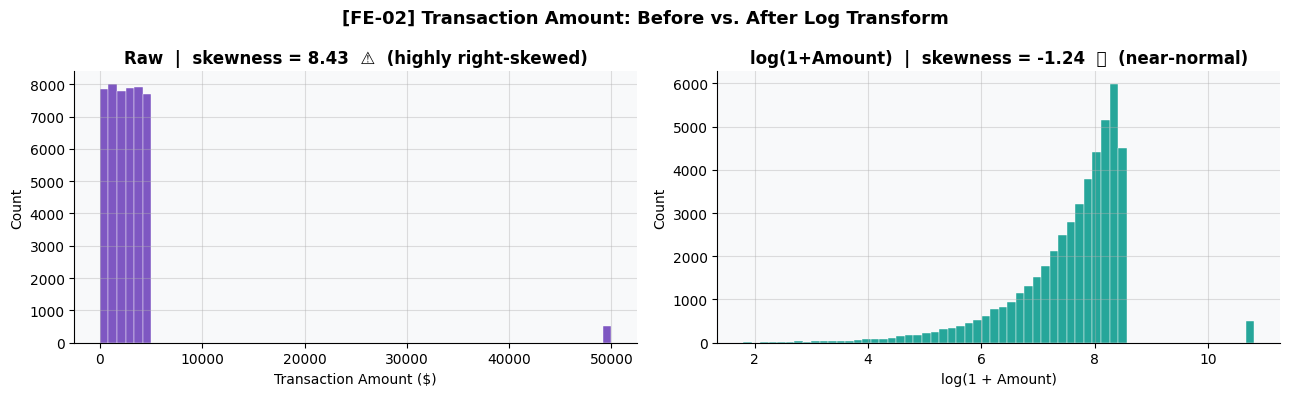

Skewness reduced: 8.43 → -1.24
75th percentile of log_amount (used as threshold in FE-06): 8.2391


In [5]:
raw_amt = df['Transaction_Amount'].dropna()
log_amt = np.log1p(raw_amt)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('[FE-02] Transaction Amount: Before vs. After Log Transform',
             fontsize=13, fontweight='bold')

axes[0].hist(raw_amt, bins=60, color='#7E57C2', edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Raw  |  skewness = {raw_amt.skew():.2f}  ⚠️  (highly right-skewed)')
axes[0].set_xlabel('Transaction Amount ($)')
axes[0].set_ylabel('Count')

axes[1].hist(log_amt, bins=60, color='#26A69A', edgecolor='white', linewidth=0.3)
axes[1].set_title(f'log(1+Amount)  |  skewness = {log_amt.skew():.2f}  ✅  (near-normal)')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Skewness reduced: {raw_amt.skew():.2f} → {log_amt.skew():.2f}')
print(f'75th percentile of log_amount (used as threshold in FE-06): {log_amt.quantile(0.75):.4f}')

[FE-03] Time-of-Day Bin Summary:


,time_of_day,count,fraud_count,fraud_rate
0,afternoon,12023,587,4.882
1,evening,11848,608,5.132
2,morning,11758,571,4.856
3,night,11985,570,4.756


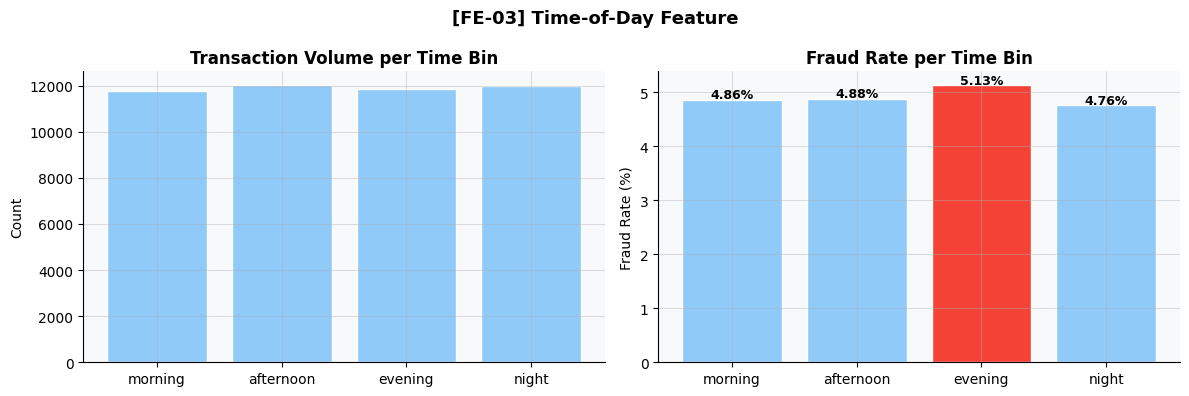

In [6]:
# Apply to a working copy for manual demonstration
df_demo = df.copy()
df_demo['time_of_day'] = pd.cut(
    df_demo['Time_of_Transaction'],
    bins=[-1, 5, 11, 17, 23],
    labels=['night', 'morning', 'afternoon', 'evening']
).astype(str)

# Verify: count distribution and fraud rate per bin
tod_summary = df_demo.groupby('time_of_day').agg(
    count      = ('Fraudulent', 'count'),
    fraud_count= ('Fraudulent', 'sum'),
    fraud_rate = ('Fraudulent', 'mean')
).reset_index()
tod_summary['fraud_rate'] = (tod_summary['fraud_rate'] * 100).round(3)

print('[FE-03] Time-of-Day Bin Summary:')
display(tod_summary)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('[FE-03] Time-of-Day Feature', fontsize=13, fontweight='bold')

order = ['morning', 'afternoon', 'evening', 'night']
subset = tod_summary.set_index('time_of_day').reindex(order).reset_index()

axes[0].bar(subset['time_of_day'], subset['count'],
            color='#90CAF9', edgecolor='white')
axes[0].set_title('Transaction Volume per Time Bin')
axes[0].set_ylabel('Count')

bars = axes[1].bar(subset['time_of_day'], subset['fraud_rate'],
                   color=[FRAUD_CLR if v == subset['fraud_rate'].max()
                          else '#90CAF9' for v in subset['fraud_rate']],
                   edgecolor='white')
for bar, val in zip(bars, subset['fraud_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Fraud Rate per Time Bin')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

In [7]:
df_demo['is_unknown_device']  = (df_demo['Device_Used']    == 'Unknown Device').astype(int)
df_demo['is_invalid_payment'] = (df_demo['Payment_Method'] == 'Invalid Method').astype(int)

print('[FE-04] Unknown Device Flag:')
print(df_demo.groupby('is_unknown_device')['Fraudulent'].agg(
    count='count', fraud_rate='mean'
).assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(3)))

print('\n[FE-05] Invalid Payment Flag:')
print(df_demo.groupby('is_invalid_payment')['Fraudulent'].agg(
    count='count', fraud_rate='mean'
).assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(3)))

[FE-04] Unknown Device Flag:
                   count  fraud_rate
is_unknown_device                   
0                  48589       4.923
1                   1530       4.902

[FE-05] Invalid Payment Flag:
                    count  fraud_rate
is_invalid_payment                   
0                   48592       4.927
1                    1527       4.781


In [8]:
# Compute thresholds from the working dataset
df_demo['log_amount'] = np.log1p(df_demo['Transaction_Amount'].fillna(df_demo['Transaction_Amount'].median()))
log_75p    = df_demo['log_amount'].quantile(0.75)
age_25p    = df_demo['Account_Age'].quantile(0.25)

print(f'Thresholds computed from training data:')
print(f'  log_amount 75th pct  = {log_75p:.4f}')
print(f'  Account_Age 25th pct = {age_25p:.1f} months')

df_demo['high_amount_new_account'] = (
    (df_demo['log_amount'] > log_75p) &
    (df_demo['Account_Age'] < age_25p)
).astype(int)

print(f'\n[FE-06] Interaction Feature Distribution:')
print(df_demo.groupby('high_amount_new_account')['Fraudulent'].agg(
    count='count', fraud_rate='mean'
).assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(3)))

print(f'\nNote: {df_demo["high_amount_new_account"].sum():,} transactions match '
      f'the high-risk pattern ({df_demo["high_amount_new_account"].mean()*100:.1f}% of all transactions)')

Thresholds computed from training data:
  log_amount 75th pct  = 8.2222
  Account_Age 25th pct = 30.0 months

[FE-06] Interaction Feature Distribution:
                         count  fraud_rate
high_amount_new_account                   
0                        47033       4.971
1                         3086       4.180

Note: 3,086 transactions match the high-risk pattern (6.2% of all transactions)


[FE-07] Velocity Risk Bin Summary:


,count,fraud_rate
velocity_risk,,
high,14310,4.654
low,10642,4.990
medium,14503,5.164
very_high,10664,4.886


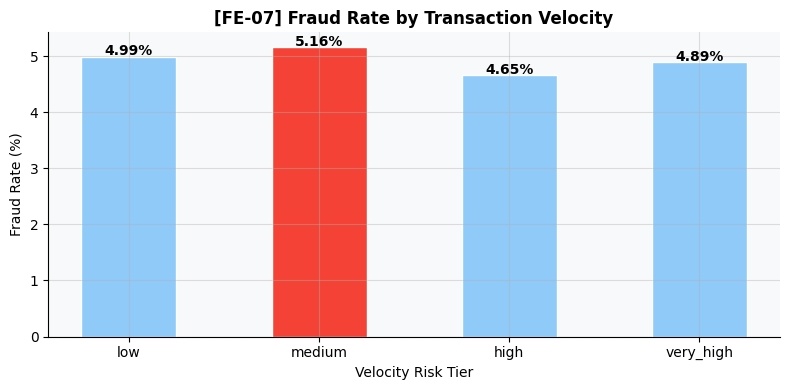

In [9]:
df_demo['velocity_risk'] = pd.cut(
    df_demo['Number_of_Transactions_Last_24H'],
    bins=[0, 3, 7, 11, float('inf')],
    labels=['low', 'medium', 'high', 'very_high']
).astype(str)

vel_summary = df_demo.groupby('velocity_risk')['Fraudulent'].agg(
    count='count', fraud_rate='mean'
).assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(3))

print('[FE-07] Velocity Risk Bin Summary:')
display(vel_summary)

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
order = ['low', 'medium', 'high', 'very_high']
rates = vel_summary.reindex(order)['fraud_rate']
bars = ax.bar(order, rates.values,
              color=[FRAUD_CLR if v == rates.max() else '#90CAF9' for v in rates.values],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('[FE-07] Fraud Rate by Transaction Velocity')
ax.set_xlabel('Velocity Risk Tier')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

In [10]:
# Column inventory: original vs. new
original_cols  = list(df.columns)
engineered_cols = ['log_amount', 'time_of_day', 'is_unknown_device',
                   'is_invalid_payment', 'high_amount_new_account', 'velocity_risk']

print('=== ORIGINAL COLUMNS ===')
for c in original_cols:
    print(f'  {c}')

print(f'\n=== NEW ENGINEERED FEATURES (added in Phase 2) ===')
for c in engineered_cols:
    dtype = df_demo[c].dtype
    sample = df_demo[c].iloc[0]
    print(f'  {c:<30} dtype={dtype}  sample={sample}')

print(f'\nTotal columns before encoding: {len(df_demo.columns)}')
print(f'Missing values remaining: {df_demo[engineered_cols + ["Transaction_Amount"]].isnull().sum().sum()}')

=== ORIGINAL COLUMNS ===
  Transaction_ID
  User_ID
  Transaction_Amount
  Transaction_Type
  Time_of_Transaction
  Device_Used
  Location
  Previous_Fraudulent_Transactions
  Account_Age
  Number_of_Transactions_Last_24H
  Payment_Method
  Fraudulent

=== NEW ENGINEERED FEATURES (added in Phase 2) ===
  log_amount                     dtype=float64  sample=7.165307986452406
  time_of_day                    dtype=str  sample=afternoon
  is_unknown_device              dtype=int64  sample=0
  is_invalid_payment             dtype=int64  sample=0
  high_amount_new_account        dtype=int64  sample=0
  velocity_risk                  dtype=str  sample=very_high

Total columns before encoding: 18
Missing values remaining: 4981


Sklearn Pipline 

In [11]:
pipeline = build_preprocessing_pipeline()

print('Pipeline structure:')
print(pipeline)
print('\nPipeline steps:')
for name, step in pipeline.steps:
    print(f'  [{name}] → {type(step).__name__}')

Pipeline structure:
Pipeline(steps=[('engineer', FraudFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_amount',
                                                   'Time_of_Transaction',
                                                   'Previous_Fraudulent_Transactions',
                                                   'Account_Age',
                                                   'Number_of_Transactions_Last_24H']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Transaction_Type',
                                                   'Devic

Train - Test split

In [12]:
X = df.drop(columns=['Fraudulent'])
y = df['Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   # CRITICAL: preserve class balance
)

print('Split summary:')
print(f'  Training set   : {len(X_train):,} rows  →  {y_train.sum():,} fraud  ({y_train.mean()*100:.2f}%)')
print(f'  Test set       : {len(X_test):,}  rows  →  {y_test.sum():,}  fraud  ({y_test.mean()*100:.2f}%)')
print(f'  Total          : {len(X):,} rows')
print(f'\n  ✅ Fraud rate preserved in both sets (stratify=y worked correctly)')

Split summary:
  Training set   : 40,095 rows  →  1,974 fraud  (4.92%)
  Test set       : 10,024  rows  →  493  fraud  (4.92%)
  Total          : 50,119 rows

  ✅ Fraud rate preserved in both sets (stratify=y worked correctly)


Apply and Validate the Pipeline 

In [13]:
# Fit ONLY on training data
X_train_proc = pipeline.fit_transform(X_train)

# Transform test data using training statistics
X_test_proc  = pipeline.transform(X_test)

# Extract feature names for later use in SHAP / evaluation
feature_names = get_feature_names(pipeline)

print(f'Training matrix shape  : {X_train_proc.shape}')
print(f'Test matrix shape      : {X_test_proc.shape}')
print(f'Number of features     : {len(feature_names)}')
print(f'Missing values (train) : {np.isnan(X_train_proc).sum()}')
print(f'Missing values (test)  : {np.isnan(X_test_proc).sum()}')
print(f'\n✅ Pipeline applied successfully — no missing values in output')

Training matrix shape  : (40095, 32)
Test matrix shape      : (10024, 32)
Number of features     : 32
Missing values (train) : 0
Missing values (test)  : 0

✅ Pipeline applied successfully — no missing values in output


In [14]:
print(f'All {len(feature_names)} features after engineering + encoding:\n')
print(f'{"Index":<8} {"Feature Name":<40} {"Type"}')
print('─' * 65)
for i, name in enumerate(feature_names):
    if name in NUMERIC_FEATURES:
        ftype = '📊 numeric (scaled)'
    elif name in PASSTHROUGH_FEATURES:
        ftype = '🚩 binary flag (engineered)'
    else:
        ftype = '🏷️  one-hot encoded'
    print(f'  [{i:02d}]   {name:<40} {ftype}')

All 32 features after engineering + encoding:

Index    Feature Name                             Type
─────────────────────────────────────────────────────────────────
  [00]   log_amount                               📊 numeric (scaled)
  [01]   Time_of_Transaction                      📊 numeric (scaled)
  [02]   Previous_Fraudulent_Transactions         📊 numeric (scaled)
  [03]   Account_Age                              📊 numeric (scaled)
  [04]   Number_of_Transactions_Last_24H          📊 numeric (scaled)
  [05]   Transaction_Type_Bank Transfer           🏷️  one-hot encoded
  [06]   Transaction_Type_Bill Payment            🏷️  one-hot encoded
  [07]   Transaction_Type_Online Purchase         🏷️  one-hot encoded
  [08]   Transaction_Type_POS Payment             🏷️  one-hot encoded
  [09]   Device_Used_Mobile                       🏷️  one-hot encoded
  [10]   Device_Used_Tablet                       🏷️  one-hot encoded
  [11]   Device_Used_Unknown Device               🏷️  one-hot encod

Scaled numeric features — mean should be ~0, std should be ~1:
      log_amount  Time_of_Transaction  Previous_Fraudulent_Transactions  \
mean        -0.0                 -0.0                               0.0   
std          1.0                  1.0                               1.0   

      Account_Age  Number_of_Transactions_Last_24H  
mean         -0.0                              0.0  
std           1.0                              1.0  


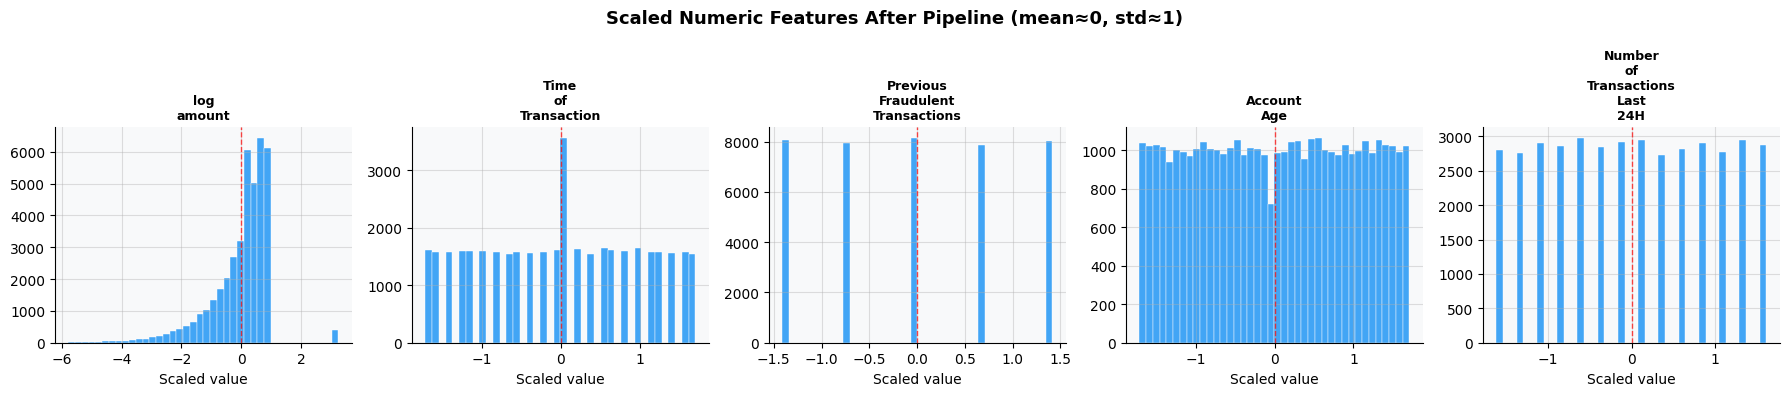

In [15]:
# Create a DataFrame from the processed array for easy inspection
df_processed = pd.DataFrame(X_train_proc, columns=feature_names)

# Check scaled numeric features
numeric_processed = df_processed[NUMERIC_FEATURES]
print('Scaled numeric features — mean should be ~0, std should be ~1:')
print(numeric_processed.agg(['mean', 'std']).round(4))

# Visualise
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(18, 4))
fig.suptitle('Scaled Numeric Features After Pipeline (mean≈0, std≈1)',
             fontsize=13, fontweight='bold')
for i, col in enumerate(NUMERIC_FEATURES):
    axes[i].hist(df_processed[col], bins=40, color='#42A5F5',
                 edgecolor='white', linewidth=0.3)
    axes[i].axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
    axes[i].set_title(col.replace('_', '\n'), fontsize=9)
    axes[i].set_xlabel('Scaled value')
plt.tight_layout()
plt.show()

Feature Summary

In [16]:


checks = {
    'No missing values in train'        : np.isnan(X_train_proc).sum() == 0,
    'No missing values in test'         : np.isnan(X_test_proc).sum() == 0,
    'Feature count matches names'       : X_train_proc.shape[1] == len(feature_names),
    'Train/test shapes compatible'      : X_train_proc.shape[1] == X_test_proc.shape[1],
    'Train fraud rate ~4.9%'            : abs(y_train.mean() - 0.049) < 0.005,
    'Test fraud rate ~4.9%'             : abs(y_test.mean() - 0.049) < 0.005,
    'Numeric features are scaled'       : abs(df_processed[NUMERIC_FEATURES].mean().mean()) < 0.1,
    'Binary flags are 0/1 only'         : df_processed[PASSTHROUGH_FEATURES].isin([0,1]).all().all(),
}

print('Feature Engineering — Readiness Checklist')
print('═' * 50)
all_pass = True
for check, result in checks.items():
    icon = '✅' if result else '❌'
    print(f'  {icon}  {check}')
    if not result:
        all_pass = False

print('═' * 50)
if all_pass:
    print('  🚀 ALL CHECKS PASSED — Ready for Phase 3: Imbalance Handling')
else:
    print('  ⛔  SOME CHECKS FAILED — Review the pipeline before proceeding')

print(f"""
Summary of what was built:
  • Pipeline steps    : {len(pipeline.steps)}
  • Total features    : {len(feature_names)}
    ├── Numeric        : {len(NUMERIC_FEATURES)} (StandardScaler applied)
    ├── One-hot        : {len([f for f in feature_names if f not in NUMERIC_FEATURES + PASSTHROUGH_FEATURES])} (from {len(CATEGORICAL_FEATURES)} original columns)
    └── Binary flags   : {len(PASSTHROUGH_FEATURES)} (engineered anomaly signals)
  • Training samples  : {X_train_proc.shape[0]:,}
  • Test samples      : {X_test_proc.shape[0]:,}
  • Reusable module   : src/features.py  ← imported by training script AND API
""")

Feature Engineering — Readiness Checklist
══════════════════════════════════════════════════
  ✅  No missing values in train
  ✅  No missing values in test
  ✅  Feature count matches names
  ✅  Train/test shapes compatible
  ✅  Train fraud rate ~4.9%
  ✅  Test fraud rate ~4.9%
  ✅  Numeric features are scaled
  ✅  Binary flags are 0/1 only
══════════════════════════════════════════════════
  🚀 ALL CHECKS PASSED — Ready for Phase 3: Imbalance Handling

Summary of what was built:
  • Pipeline steps    : 2
  • Total features    : 32
    ├── Numeric        : 5 (StandardScaler applied)
    ├── One-hot        : 24 (from 6 original columns)
    └── Binary flags   : 3 (engineered anomaly signals)
  • Training samples  : 40,095
  • Test samples      : 10,024
  • Reusable module   : src/features.py  ← imported by training script AND API

